# Team 18 — Ablation Study
**Goal**: Show how model accuracy changes as we add more features step by step.

This answers: *"Do all 19 features contribute? Which ones matter most?"*

Reads directly from `features.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ── Load dataset ──
df = pd.read_csv('features.csv')
print(f'Loaded {len(df)} rows')
print('Columns:', list(df.columns))
print('Label distribution:')
print(df['energy_label'].value_counts())

Loaded 999 rows
Columns: ['genre', 'filename', 'rms', 'zcr', 'centroid', 'flux', 'tempo', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'energy_label']
Label distribution:
energy_label
Medium    380
Low       329
High      290
Name: count, dtype: int64


In [2]:
# ── Define feature groups (added one group at a time) ──
mfcc_cols = [f'mfcc_{i}' for i in range(1, 14)]

feature_groups = [
    ('RMS only',                     ['rms']),
    ('+ ZCR',                        ['rms', 'zcr']),
    ('+ Spectral Centroid',          ['rms', 'zcr', 'centroid']),
    ('+ Spectral Flux',              ['rms', 'zcr', 'centroid', 'flux']),
    ('+ Tempo',                      ['rms', 'zcr', 'centroid', 'flux', 'tempo']),
    ('+ All MFCC (full 19)',         ['rms', 'zcr', 'centroid', 'flux', 'tempo'] + mfcc_cols),
]

# ── Train/test split (same seed as notebook.ipynb) ──
y = df['energy_label']
X_train_idx, X_test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=y
)

results = []

for name, cols in feature_groups:
    X_train = df.loc[X_train_idx, cols]
    X_test  = df.loc[X_test_idx,  cols]
    y_train = y.loc[X_train_idx]
    y_test  = y.loc[X_test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))

    results.append({'Features': name, 'Accuracy': round(acc * 100, 1), 'N': len(cols)})
    print(f'{name:45s} → {acc*100:.1f}%')

results_df = pd.DataFrame(results)
print('\nDone ✅')

RMS only                                      → 55.5%
+ ZCR                                         → 58.0%
+ Spectral Centroid                           → 58.0%
+ Spectral Flux                               → 60.5%
+ Tempo                                       → 89.5%
+ All MFCC (full 19)                          → 84.5%

Done ✅


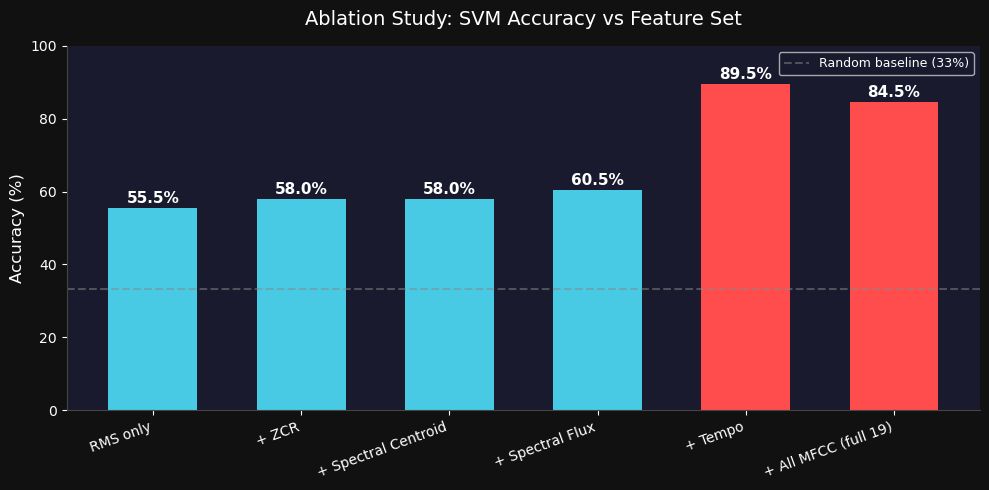

Saved as ablation_study.png ✅


In [3]:
# ── Plot ablation results ──
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#1a1a2e')

colors = ['#48cae4' if acc < 70 else '#70e000' if acc < 82 else '#ff4d4d'
          for acc in results_df['Accuracy']]

bars = ax.bar(range(len(results_df)), results_df['Accuracy'],
              color=colors, edgecolor='none', width=0.6)

# Add value labels on bars
for bar, acc in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc}%', ha='center', va='bottom',
            color='white', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Features'], rotation=20, ha='right',
                   color='white', fontsize=10)
ax.set_ylabel('Accuracy (%)', color='white', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Ablation Study: SVM Accuracy vs Feature Set', color='white', fontsize=14, pad=15)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Baseline reference line
ax.axhline(y=33.3, color='#888888', linestyle='--', alpha=0.5, label='Random baseline (33%)')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved as ablation_study.png ✅')

In [4]:
# ── Print summary table for report ──
print('=== Ablation Study Results ===')
print(results_df[['Features', 'N', 'Accuracy']].to_string(index=False))
print()
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f'Best configuration: {best["Features"]} ({best["Accuracy"]}%)')

# Delta analysis
print('\n=== Accuracy gain per feature group added ===')
for i in range(1, len(results_df)):
    delta = results_df.iloc[i]['Accuracy'] - results_df.iloc[i-1]['Accuracy']
    sign = '+' if delta >= 0 else ''
    print(f'  Adding {results_df.iloc[i]["Features"].split("+")[-1].strip():30s}: {sign}{delta:.1f}%')

=== Ablation Study Results ===
            Features  N  Accuracy
            RMS only  1      55.5
               + ZCR  2      58.0
 + Spectral Centroid  3      58.0
     + Spectral Flux  4      60.5
             + Tempo  5      89.5
+ All MFCC (full 19) 18      84.5

Best configuration: + Tempo (89.5%)

=== Accuracy gain per feature group added ===
  Adding ZCR                           : +2.5%
  Adding Spectral Centroid             : +0.0%
  Adding Spectral Flux                 : +2.5%
  Adding Tempo                         : +29.0%
  Adding All MFCC (full 19)            : -5.0%
